# A01 - Your Town, Your Agent, Your Map

*Released Monday 14 September, due Friday 25 September at 23:59. Ten points, complete or incomplete.*

In the first precept we made a map of Princeton, proved it was the right Princeton, and had an agent answer a question we had first attempted ourselves. Now you do the same for a place you actually care about, your hometown, a town you lived in, a city you love, or the neighbourhood you grew up in. The place is yours to choose, and the choice is part of the work, because the questions worth asking about a place come from knowing it.

**Everything you need is in this notebook**, including the checklist you will be marked against. If you were not in the room for the precept or the lecture, you are not at a disadvantage.

## How this notebook works

Five things, in order.

1. **Getting the folder.** You got it by opening GitHub Desktop and clicking *Pull origin*. In a Codespace it is *Source Control*, then the three dots menu, then *Pull*. The folder is called `A01` and holds this notebook and a `data` folder beside it.
2. **Making it yours.** Before anything else, choose *File*, then *Save As*, and save this notebook in the same `A01` folder under a name with `-mywork` in it, for example `a01-hackl-mywork.ipynb`. It has to stay beside the `data` folder, because that is where it reads its files from. Files with `-mywork` in the name are ignored by the course repository, so nothing you write can be overwritten when you pull next week's material.
3. **Running it once, untouched.** Click *Restart* and then *Run All*, the two buttons in the toolbar above the notebook, before you change anything. If VS Code asks for a kernel, choose *Urban AI (Python 3.12)*. The notebook runs on Princeton, every code cell gets a number in its margin, and nothing turns red. Now you have seen the whole thing work, and you know what working looks like.
4. **Then making it yours.** The settings cell below is the only code you have to change. Cells that begin with *Your answer here* are where you write. Task C has one cell where you paste what your agent gave you. Everything else you only run.
5. **How long.** Budget about three hours, spread over more than one sitting.

## What you are marked against

This is the whole grading contract. Work that meets every line is complete and earns the full ten points. Tick them yourself before you submit, because that is what a specification is for.

- [ ] The notebook runs from top to bottom without errors after Restart and then Run All
- [ ] A place of your own choosing is used, or the pinned Princeton lane is taken with one kind of amenity and an anchor other than Nassau Hall
- [ ] Both maps are present, the static one and the interactive one
- [ ] The walk radius question is answered for a point you chose, computed in a coordinate system measured in metres
- [ ] The three checks are run on your own data, with one sentence of interpretation each
- [ ] A written specification is included for the step you delegated
- [ ] The audit of the agent's work names what you checked, or an honest report says what you tried instead
- [ ] A few sentences interpret what you found, including what the data misses
- [ ] The AI note is present, three lines, at the end of the notebook

If something is missing when I check, you get feedback and two weeks to add it. Submit on time and that safety net applies; nothing can be revised after Dean's Date.

## Settings

This is the only cell you have to change. Everything below reads from it, so once you have set your place and your anchor here you can run the whole notebook from the top.

Three of the lines are for later. Leave `USE_LIVE_OSM` as `False` until you have read the next section, choose `AMENITY` once you have seen the table of what is in your data, and set the anchor in Task B.

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

In [2]:
PLACE = "Princeton, New Jersey"   # the place the live lane fetches, with its state or country
USE_LIVE_OSM = False              # True fetches PLACE from OpenStreetMap once; set it back to False afterwards
AMENITY = "all"                   # "all", or one kind from the table further down, for example "cafe"

ANCHOR_NAME = "Nassau Hall"       # the point you measure from, set in Task B
ANCHOR_LAT = 40.34877             # latitude, the number your phone shows first
ANCHOR_LON = -74.65927            # longitude, negative in the Americas

WALK_RADIUS_M = 400               # how far a short walk is, in metres

## Task A, part one: the data for your place

There are two lanes through this assignment and **both are fully accepted**.

**The pinned lane** is what you have right now. A snapshot of Princeton sits in the `data` folder beside this notebook, the municipal boundary as published by the State of New Jersey, and the places to eat taken from OpenStreetMap on 2026-08-29. If you take this lane, you must choose one kind of amenity rather than all of them, in `AMENITY`, and an anchor point other than Nassau Hall, so that your work is your own.

**The live lane** fetches a place you choose. Put your town in `PLACE`, with its state or country, set `USE_LIVE_OSM = True`, and run the notebook from the top. The fetch cell saves what it finds into the `data` folder and tells you to set the switch back to `False`, and from then on the notebook reads your files from disk.

A word about where that data comes from, because it shapes what you can say about it. **OpenStreetMap** is a map of the world built by volunteers, in the same spirit as Wikipedia. Anybody can add a building or a restaurant. The consequence is that its gaps are not random: busy places get mapped, quiet ones do not, and a town where somebody ran a mapping party looks richer than its neighbour. Whatever you conclude about your place, you are partly describing who bothered to map it. The data is licensed ODbL and requires attribution, which is why the credit travels inside the files.

Two more terms you will meet in the code. **Geocoding** is turning a name like "Heidelberg, Germany" into a shape, and it is a guess: the service picks the most likely match, and it is occasionally wrong in ways only you can spot. An **amenity tag** is OpenStreetMap's own vocabulary for what kind of place something is, which is why we have to ask for `restaurant` and `cafe` by their exact names.

Live services fail. Yours may time out or return nothing, and that is not your fault. If it does, the fetch cell says so and the notebook carries on with the Princeton data. Take the pinned lane in that case; you lose no marks whatsoever.

The pattern in the next cell is worth understanding, because it is how professional work with live data is done. We **fetch once, save the result, and then read the saved copy**. A live service is not a dataset. A notebook that re-fetches every time cannot be re-run next week, cannot be graded, and cannot be reproduced by anybody else.

The cell is longer than the others because it is careful. It checks that the name resolved to a real boundary rather than to a marker, it tidies what comes back, and if anything goes wrong it says so and lets the notebook carry on. You do not need to understand every line of it, only the switch at the top and the message it prints at the end.

One piece of the tidying deserves a sentence. A restaurant can be mapped in two ways, as a single dot or as the outline of the building it occupies, and both are in the data. To count places we want one dot each, so the cell replaces every outline with its **centroid**, the balance point of the shape. A centroid is a geometric calculation, and geometry must never be done in degrees, so the cell moves the data into a coordinate system measured in metres first, takes the centroids there, and moves back. Which metric system? It asks the data, with `estimate_utm_crs()`, and Task B comes back to what that returns.

The indented lines belong to the `if`, i.e. they happen only when the switch is `True`:

In [3]:
if USE_LIVE_OSM:
    import osmnx as ox

    ox.settings.requests_timeout = 120   # give up after two minutes rather than hang
    ox.settings.use_cache = False        # every fetch is a real fetch, so a retry is a real retry

    try:
        boundary = ox.geocode_to_gdf(PLACE)
        print(f"OpenStreetMap matched {PLACE!r} to: {boundary['display_name'].iloc[0]}")

        shape = boundary.geometry.iloc[0]
        if shape.geom_type not in ("Polygon", "MultiPolygon") or shape.equals(shape.envelope):
            raise ValueError("the name resolved to a marker or a box, not to a town boundary")
        if boundary.to_crs(boundary.estimate_utm_crs()).geometry.area.iloc[0] < 100_000:
            raise ValueError("the name resolved to a single building, not to a town boundary; use the town's name")
        if not shape.is_valid:
            boundary["geometry"] = boundary.geometry.make_valid()   # repairs a self-touching outline
            shape = boundary.geometry.iloc[0]

        places = ox.features_from_polygon(
            shape, {"amenity": ["restaurant", "cafe", "fast_food", "bar", "pub", "ice_cream"]}
        )
        places = places.reset_index()
        for column in ("name", "amenity"):
            if column not in places.columns:   # a small town may have nothing named
                places[column] = None
        places = places[["name", "amenity", "geometry"]]

        metric = places.estimate_utm_crs()
        places["geometry"] = places.to_crs(metric).geometry.centroid.to_crs(places.crs)

        boundary["name"] = PLACE
        boundary = boundary[["name", "display_name", "geometry"]]
        boundary.to_file("data/my_boundary.geojson", driver="GeoJSON")
        places.to_file("data/my_food.geojson", driver="GeoJSON")

        print(f"Fetched {len(places)} places to eat and saved both files in the data folder.")
        print("Now set USE_LIVE_OSM = False in the settings cell. The notebook reads your files from disk from here on.")

    except Exception as error:
        print(f"The fetch did not work. {type(error).__name__}: {error}")
        print("Nothing was saved. Wait a few minutes and try once more, add the state or country to PLACE,")
        print("or set USE_LIVE_OSM = False and carry on with the pinned Princeton data. Both lanes are fully accepted.")

From here on, both lanes are identical. The next cell looks for the two files the live lane saves, `data/my_boundary.geojson` and `data/my_food.geojson`, reads them if they are there, and otherwise reads the Princeton snapshot. It prints which lane you are on and which place it loaded, so read that line every time. If you fetched a place and want Princeton back, delete those two files from the `data` folder.

In [4]:
my_boundary = Path("data/my_boundary.geojson")   # written by the live lane, if you took it
my_food = Path("data/my_food.geojson")

if my_boundary.exists() and my_food.exists():
    lane = "the live lane, your own fetch"
    boundary = gpd.read_file(my_boundary)
    all_food = gpd.read_file(my_food)
else:
    lane = "the pinned lane, the Princeton snapshot"
    boundary = gpd.read_file("data/princeton_boundary.geojson")
    all_food = gpd.read_file("data/princeton_food.geojson")

place_name = boundary["name"].iloc[0]

print(f"Lane:   {lane}")
print(f"Place:  {place_name}")
if "display_name" in boundary.columns:
    print(f"Matched by OpenStreetMap as: {boundary['display_name'].iloc[0]}")
print(f"Loaded: {len(boundary)} boundary polygon and {len(all_food)} places to eat")
if PLACE != place_name:
    print(f"Note: PLACE is {PLACE!r} but the data on disk is for {place_name!r}. To fetch {PLACE}, set USE_LIVE_OSM = True and run again from the top. If you are on the pinned lane on purpose, ignore this.")

Lane:   the pinned lane, the Princeton snapshot
Place:  Princeton, New Jersey
Loaded: 1 boundary polygon and 92 places to eat


Let us look at what we have. `head` shows the first few rows, and `value_counts` tells us what is actually in a column, as opposed to what we assume is in it:

In [5]:
display(all_food.head(3))
all_food["amenity"].value_counts()

,name,amenity,geometry
0,Metro North,restaurant,POINT (-74.65398 40.33471)
1,Roots Ocean Prime,restaurant,POINT (-74.65944 40.34333)
2,Starbucks,cafe,POINT (-74.65946 40.34993)


amenity
restaurant    52
fast_food     16
cafe          15
ice_cream      6
pub            2
bar            1
Name: count, dtype: int64

That second table is your vocabulary. It lists every kind of place in your data and how many of each there are, and it is where you choose `AMENITY`. On the pinned lane, pick one kind, put its exact spelling into the settings cell, for example `AMENITY = "cafe"`, and run the notebook from the top again. On the live lane you may keep `"all"`, or narrow it in the same way if you like. A misspelt kind matches nothing, so the next cell warns you and carries on with all places until you fix it.

Note whether any count surprises you. A town with two hundred restaurants and no cafes is telling you something about its mappers as much as about its high street.

In [6]:
if AMENITY == "all":
    food = all_food
    label = "places to eat"
else:
    food = all_food[all_food["amenity"] == AMENITY]
    label = f"{AMENITY} places"

if len(food) == 0:
    print(f"WARNING: no rows have amenity == {AMENITY!r}. Check the spelling against the table above, fix it in the settings cell, and run again from the top.")
    print("Until then the notebook carries on with all places to eat, so that nothing below breaks.")
    food = all_food
    label = "places to eat"

print(f"Keeping {len(food)} {label} in {place_name}")

Keeping 92 places to eat in Princeton, New Jersey


## Task A, part two: two maps

Now make two maps of your place, the way we did in the precept.

**The static map** layers the boundary and the food points on one pair of axes. The pattern is: draw the boundary first and keep the drawing surface it hands back, then draw the food onto that same surface by passing `ax=ax`. Whatever is drawn last sits on top.

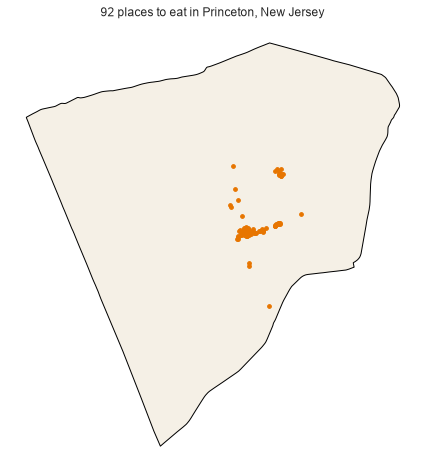

In [7]:
ax = boundary.plot(figsize=(8, 8), color="#f5f0e6", edgecolor="black", linewidth=1)
food.plot(ax=ax, color="#e77500", markersize=14)

ax.set_title(f"{len(food)} {label} in {place_name}")
ax.set_axis_off()

**The interactive map** uses `explore` instead of `plot`, and gives you something you can zoom and click. The `tooltip` argument takes a list of column names, and those are what appear when you hover.

Note that we pass only two light layers. An interactive map writes every shape into the page, so a large layer will make your browser crawl. Rendering cost is a real design constraint.

In [8]:
webmap = boundary.explore(color="#e77500", style_kwds={"fill": False, "weight": 3})
webmap = food.explore(m=webmap, color="#e77500", tooltip=["name", "amenity"])
webmap

**Now write.** In the cell below, a few sentences on two things.

First, what does the food landscape of your place look like? Where is it concentrated, and does that match what you know about the town from having been there?

Second, and more interestingly, what is missing from the data? You know this place. Name something you are confident exists and check whether it is here. Remember that every dataset is a claim about the world made by whoever collected it, and that OpenStreetMap's gaps are not random.

*Your answer here. Double-click this cell to write in it, and press Shift+Enter when you are done so it turns back into text.*

## Task B, part one: the three checks

A map that renders is not a map that is right. Before we compute anything from this data, we ask it three questions.

**One, what are the units?** `.crs` reports the coordinate reference system. `EPSG:4326` means degrees of longitude and latitude, which is what OpenStreetMap and your phone both use. Anything measured in degrees cannot give you a distance or an area directly.

**Two, where on Earth is it?** `.total_bounds` gives four numbers in the order minimum x, minimum y, maximum x, maximum y, i.e. west, south, east, north. A degree of latitude is about 111 kilometres everywhere, so you can convert a discrepancy into kilometres in your head. If the signs are wrong you will be in the wrong hemisphere, which is a surprisingly common way to lose an afternoon.

**Three, how big is it?** Area needs a metric system, so we reproject first, then divide square metres by a million to get square kilometres. An answer that is an order of magnitude out usually means you loaded the county rather than the town.

Which metric system? For Princeton we used `EPSG:26918` in the precept. For your town that would be wrong, so rather than looking it up we ask the data. `estimate_utm_crs()` reads the bounds of your own layer and returns the metric system designed for that strip of the world. Note that it may hand you `EPSG:32618` where the precept used `EPSG:26918`, even for Princeton itself. Those two are the same strip of the world measured in metres, differing only in the reference model of the Earth's shape, and either is right here. Noticing the difference and saying which you used is exactly the care this assignment is looking for.

Run them on your own boundary:

In [9]:
metric = boundary.estimate_utm_crs()

print(f"crs           {boundary.crs}")
print(f"metric crs    {metric}")
print(f"total bounds  {boundary.total_bounds}")
print(f"area          {boundary.to_crs(metric).geometry.area.iloc[0] / 1e6:.2f} square kilometres")

crs           EPSG:4326
metric crs    EPSG:32618
total bounds  [-74.72214312  40.30487983 -74.61748589  40.39105584]
area          47.66 square kilometres


To judge those numbers you need something to compare them against. If you are on the pinned lane, the reference values for Princeton ship beside the data and can be read rather than remembered. If you fetched your own place, look its area up in an encyclopedia or on the town's own website, and name the source when you write:

In [10]:
reference = json.load(open("data/ground_truth.json"))
print(json.dumps(reference["boundary"], indent=2))

{
  "area_km2": 47.66,
  "total_bounds": [
    -74.7221,
    40.3049,
    -74.6175,
    40.3911
  ]
}


**Now write.** One sentence per check, in the cell below.

What is the coordinate reference system of your data, and what are its units? Where do the bounds place your data, and is that where you expect? And does the area match the place you think you loaded, judged against something independent, for example what an encyclopedia says the town's area is? Name the source you compared against.

*Your answer here. Double-click this cell to write in it, and press Shift+Enter when you are done so it turns back into text.*

## Task B, part two: the walk radius

**How many places to eat are within a `WALK_RADIUS_M` walk of your anchor point?**

Pick a point that means something to you, your old school, a flat you lived in, a corner you know. Set `ANCHOR_NAME`, `ANCHOR_LAT` and `ANCHOR_LON` in the settings cell at the top. You can get the two numbers by pressing and holding on the spot in your phone's map application, or on a laptop by right-clicking the spot in Google Maps, where they appear at the top of the menu, latitude first.

**Watch the order.** Phone and map applications show latitude first. Code wants longitude first, because longitude is x. Getting this backwards puts your anchor in the wrong hemisphere without any error at all, which is why the first cell below checks that your anchor lies inside the boundary you loaded before anything is counted.

The method has four steps, and you have seen every one of them work in the precept:

1. Put both the anchor and the food into a coordinate system measured in metres.
2. Grow a circle of that radius around the anchor. That circle is called a **buffer**.
3. Ask, for every place to eat, whether it falls inside the circle.
4. Count the answers that came back true.

Step four is a `.sum()`, because Python counts `True` as one and `False` as zero.

One trap to know about. `EPSG:3857`, called Web Mercator, is measured in metres and is the most common projected system in the world, so it looks like a safe choice. At Princeton's latitude it is wrong by about thirty percent, and a buffer computed in it silently returns the wrong answer. The recipe below uses `metric`, the system your own data suggested in the three checks.

The recipe is written out for you, the same four steps we ran for Nassau Hall in the precept. Run it on your own anchor and read your number. In Task C you hand the same question to your agent, and this number is what you check its answer against.

In [11]:
anchor = gpd.GeoDataFrame(
    {"name": [ANCHOR_NAME]},
    geometry=gpd.points_from_xy([ANCHOR_LON], [ANCHOR_LAT]),   # x first, and x is longitude
    crs="EPSG:4326",
)

if anchor.within(boundary.geometry.iloc[0]).iloc[0]:
    print(f"{ANCHOR_NAME} lies inside the boundary of {place_name}. Good.")
else:
    print(f"WARNING: {ANCHOR_NAME} lies outside the boundary of {place_name}.")
    print("Either ANCHOR_LAT and ANCHOR_LON are swapped in the settings cell, or the anchor is not in the place you loaded.")

Nassau Hall lies inside the boundary of Princeton, New Jersey. Good.


In [12]:
anchor_metres = anchor.to_crs(metric).geometry.iloc[0]   # step 1, into metres
food_metres = food.to_crs(metric)                        # step 1, the same for the food

circle = anchor_metres.buffer(WALK_RADIUS_M)             # step 2, the circle
inside = food_metres.within(circle)                      # step 3, inside or not, one True or False per row
answer = int(inside.sum())                               # step 4, count the trues

print(f"{answer} of {len(food)} {label} within {WALK_RADIUS_M} m of {ANCHOR_NAME}")

55 of 92 places to eat within 400 m of Nassau Hall


Look at what you asked for. The star is your anchor, the shaded disc is the buffer, the orange dots are the places inside it and the grey dots are the ones that missed. Notice how many grey dots sit just outside the edge; the answer is sensitive to the radius, which means the radius is a decision you made, not a fact about your town:

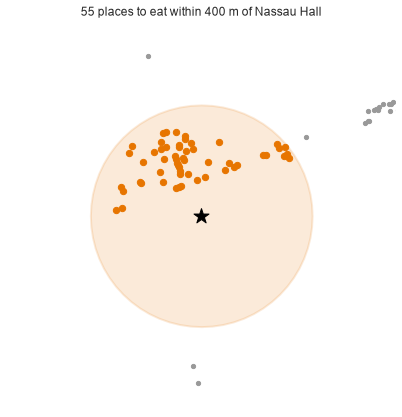

In [13]:
ax = gpd.GeoSeries([circle], crs=metric).plot(
    figsize=(7, 7), color="#e77500", alpha=0.15, edgecolor="#e77500", linewidth=2)
food_metres.plot(ax=ax, color="#999999", markersize=18)
if answer:
    food_metres[inside].plot(ax=ax, color="#e77500", markersize=40)
gpd.GeoSeries([anchor_metres], crs=metric).plot(ax=ax, color="black", marker="*", markersize=250)

view = anchor_metres.buffer(WALK_RADIUS_M * 1.75).bounds
ax.set_xlim(view[0], view[2])
ax.set_ylim(view[1], view[3])
ax.set_title(f"{answer} {label} within {WALK_RADIUS_M} m of {ANCHOR_NAME}")
ax.set_axis_off()

**Now write.** One sentence giving your number, and one sentence on what that number does not capture.

For the second sentence, remember that we measured in a straight line while people walk along streets, so a straight line always overcounts. Think about what is between your anchor and those places: a river, a railway, a motorway, a locked campus gate.

*Your answer here. Double-click this cell to write in it, and press Shift+Enter when you are done so it turns back into text.*

## Task C: delegate one step, and audit it

At least one step of this assignment must be done with a coding agent, and this is the part that matters most.

A coding agent is a program that writes code for you. This course provides one in your editor, and any other is equally acceptable. What the course grades is never which tool you used, but what it did and what you checked.

You now hold a number and a map from Task B. Hand the same question to your agent, so that you have something to check its answer against, exactly as we did in the precept.

The habit that makes it work is to **write the specification before you ask**. Not because the agent needs it, but because you do: if you cannot say what a correct answer would look like, you cannot recognise one when it arrives.

Here is the template, and then the same template filled in for the walk radius question, so you can see the level of detail that works. Adapt the names, the radius and the place to your own settings:

```text
PLACE:  which data, which file, which coordinate system
TASK:   what to compute, in what units
OUTPUT: what you want back, a number, a map, a table

Constraints: work only in this notebook, geopandas only, do not modify
earlier cells, do not install new packages.
```

```text
PLACE:  the GeoDataFrames `anchor` and `food`, already loaded in this
        notebook, both in EPSG:4326
TASK:   count the places in `food` within 400 metres of the point in
        `anchor`, measuring in a straight line, in a coordinate system
        measured in metres and appropriate for this location
OUTPUT: the count as a single integer, printed, plus a map showing the
        circle over the food points

Constraints: work only in this notebook, geopandas only, do not modify
earlier cells, do not install new packages.
```

The constraint about packages matters. Your environment is pinned so that everybody has the same one, and an agent that installs something to solve a problem has quietly made your setup different from everybody else's.

Write your own specification in the cell below, then give it to your agent.

*Your answer here. Double-click this cell to write in it, and press Shift+Enter when you are done so it turns back into text.*

```text
PLACE:

TASK:

OUTPUT:

Constraints: work only in this notebook, geopandas only, do not modify
earlier cells, do not install new packages.
```

In [14]:
# Paste your agent's code here. Read it before you run it.

**Now audit it,** and write what you found in the cell below.

**One, is the buffer computed in a coordinate system measured in metres, and one that is honest about distance where you are?** Degrees are the obvious trap. Web Mercator is the subtle one.

**Two, does the count match the number Task B gave you, and if it differs, can you say exactly why?** A different answer is not automatically wrong. An agent that counted bakeries, or measured from a building centre rather than a door, has made a defensible choice. What is not acceptable is an answer you cannot account for.

**Three, is the circle actually on your anchor?** Draw it and look. The fastest way to catch a wrong point is to see where the circle landed.

Even when the agent got everything right, say what each check would have caught. An unverified right answer is luck rather than skill.

**If you could not get any agent to work for you,** say so plainly here, describe what you tried, and show how you did the step by hand instead. An honest failure report satisfies this task completely. What does not satisfy it is silence.

*Your answer here. Double-click this cell to write in it, and press Shift+Enter when you are done so it turns back into text.*

## Your AI note

Every submission in this course carries three lines: which tools you used, what they did, and what you verified yourself. It is not a confession, it is the same professional habit as citing a source. An accurate note makes the work your own in the sense of the honour pledge.

Here is one that would earn full marks, and then a blank one for you:

```text
Tools:    Antigravity (Gemini 3 Pro) for the buffer code
They did: wrote the reprojection and buffer cell I specified
Verified: CRS is metric, count matches my hand count of the
          markers, circle is on my school not the town hall
```

*Your answer here. Double-click this cell to write in it, and press Shift+Enter when you are done so it turns back into text.*

```text
Tools:
They did:
Verified:
```

## Before you hand in

1. Click *Restart* and then *Run All* in the toolbar, then scroll the whole notebook looking for red. Checklist line one is exactly this.
2. Re-read the checklist at the top of this notebook and tick every line.
3. Save.
4. Zip the whole `A01` folder, the notebook together with its `data` folder, and name the zip `a01-yourname.zip`. Right-click the folder and choose *Compress* on a Mac, or *Send to* and then *Compressed folder* on Windows. In a Codespace, right-click the `A01` folder in the file list, choose *Download*, and compress it on your laptop.
5. Upload the zip on Canvas under A01 by Friday 25 September, 23:59.

The folder rather than the file, because a notebook that reads data is not one file. If you took the live lane, your fetched data is in there too, and it is the only copy of what you actually used.

## When something goes wrong

Most of what goes wrong in this assignment is on this list, and none of it is your fault. Start here, then the troubleshooting guide in `docs/troubleshooting.org`, then the A01 thread on the Canvas forum.

| What happened | What it means and what to do |
|---|---|
| The name resolved to a marker, a box or a single building | The service picked a place marker or a building, not a town boundary. The fetch cell refuses it and saves nothing. Use the town's official name, and add the state or country. |
| The boundary looks right and is the wrong town | Same name elsewhere. The fetch cell prints what OpenStreetMap matched, and the bounds check catches it. Compare `total_bounds` with a map you trust. |
| The fetch timed out, or returned zero features | Overpass is busy or answered with nothing. The cell prints the error, saves nothing, and the notebook carries on with Princeton. Wait, retry once, then set `USE_LIVE_OSM = False` and take the pinned lane. |
| Everything is in the Indian Ocean, or the anchor check says outside | Latitude before longitude. In code x comes first and x is longitude, which in the Americas is negative. |
| It ran a long time, or gave up after two minutes | You chose a metropolis or the service is slow. Choose a town or a district, or take the pinned lane, which is fully accepted. |
| `estimate_utm_crs()` gave a number that is not 26918 | Correct. Your place is in a different zone, or it is 32618 for Princeton itself. Use what it gave you and say so in your write-up. |
| The fetch runs again every time you Run All | The switch is still `True`. Set it to `False` once the two `my_` files are in the data folder; the notebook reads them from disk from then on. |
| You fetched a place and want Princeton back | Delete `data/my_boundary.geojson` and `data/my_food.geojson`. The notebook falls back to the pinned files on the next run. |
| Submitted, and I heard that the notebook cannot find its data | The data folder was not in the zip. Zip the folder, resubmit; the revision cycle exists for this. |

## Further resources

Nothing in this assignment requires anything below.

**The libraries.** The GeoPandas user guide covers everything with `gpd` in front of it: https://geopandas.org/en/stable/docs/user_guide.html. The osmnx documentation explains geocoding and feature queries in detail: https://osmnx.readthedocs.io.

**Coordinate systems.** Look up any EPSG number at https://epsg.io to see its units and the area it is meant for. Comparing https://epsg.io/4326 with the code your own data suggested is a worthwhile five minutes.

**The data.** The Princeton files are an OpenStreetMap extract, snapshot 2026-08-29, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright. The amenity vocabulary is documented at https://wiki.openstreetmap.org/wiki/Key:amenity. The municipal boundary is a public record from NJGIN Open Data: https://njogis-newjersey.opendata.arcgis.com.

**If you want a slower pass over Python itself,** the `F00` folder in this repository is our own foundations series, written for this course and using this same data.